<a href="https://www.kaggle.com/code/lalit7881/cpsc-product-recall-intelligence-eda?scriptVersionId=312515239" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/cpsc-product-recall-intelligence/cpsc_product_recall_intelligence.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/cpsc-product-recall-intelligence/cpsc_product_recall_intelligence.csv")

In [3]:
df.head()

,record_id,announcement_type,event_date,event_year,event_month,recall_number,product_safety_warning_number,recall_heading,name_of_product,description,...,manufacturers,importers,distributors,custom_label,custom_field,scrape_method,ingested_at_utc,date,product_safety_warning_date,original_product_safety_warning_announcement
0,cpsc_recall_26372,recall,2026-04-09,2026,4,26-372,NaN,Wybotics Recalls Robotic Pool Vacuums Due to B...,Osprey 700 Max and S1 robotic pool vacuums,This recall involves Osprey 700 Max with model...,...,"Wybotics, Co. Ltd. of Tianjin, China","Wybotics Inc. of Arcadia, California",NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"April 09, 2026",NaN,NaN
1,cpsc_recall_26385,recall,2026-04-09,2026,4,26-385,NaN,BISSELL Recalls Over One Million Steam Shot Om...,Steam Shot OmniReach and Steam Shot Omni Steam...,This recall involves certain BISSELL Steam Sho...,...,NaN,"BISSELL Homecare Inc. of Grand Rapids, Michigan",NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"April 09, 2026",NaN,NaN
2,cpsc_recall_26386,recall,2026-04-09,2026,4,26-386,NaN,Vitaquest International Recalls Multiple Iron ...,Various Brands of Iron-Containing Dietary Supp...,"This recall involves Arey, Bari Life, Bird&Be,...",...,"Vitaquest International LLC of West Caldwell, ...",NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"April 09, 2026",NaN,NaN
3,cpsc_recall_26387,recall,2026-04-09,2026,4,26-387,NaN,Easymake Adult Portable Bed Rails Recalled Due...,Easymake Adult Portable Bed Rails,This recall involves Easymake adult portable b...,...,"Zhongshan Yungu Daily Products, of China","Shenzhen Zhongfenzhigu Technology Co., Ltd., d...",NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"April 09, 2026",NaN,NaN
4,cpsc_recall_26388,recall,2026-04-09,2026,4,26-388,NaN,SNOOZ Recalls Electrical Fans Due to Fire Hazard,Breez 2-in-1 Smart Bedroom Fan and White Noise...,This recall involves the Breez 2-in-1 Smart Be...,...,NaN,"Snooz, Inc., of Las Vegas, Nevada",NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"April 09, 2026",NaN,NaN


In [4]:
df.tail()

,record_id,announcement_type,event_date,event_year,event_month,recall_number,product_safety_warning_number,recall_heading,name_of_product,description,...,manufacturers,importers,distributors,custom_label,custom_field,scrape_method,ingested_at_utc,date,product_safety_warning_date,original_product_safety_warning_announcement
9771,cpsc_recall_73021,recall,1973-09-14,1973,9,73-021,NaN,CPSC Warns Of Possible Fire Hazard,Zenith 19-inch Table Model Color Television Set,"WASHINGTON, D.C. (Sept. 14) --The Consumer Pro...",...,NaN,NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"September 14, 1973",NaN,NaN
9772,cpsc_recall_73017,recall,1973-08-27,1973,8,73-017,NaN,CPSC Bans Nine Additional Aerosol Spray Adhesi...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"August 27, 1973",NaN,NaN
9773,cpsc_recall_73015,recall,1973-08-20,1973,8,73-015,NaN,"CPSC Warns Of Electric Shock Dangers From ""Lit...",Little Wonder TV Antenna,"WASHINGTON, D.C. (August 21)--Citing the poten...",...,NaN,NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"August 20, 1973",NaN,NaN
9774,cpsc_recall_73014,recall,1973-08-19,1973,8,73-014,NaN,CPSC Bans Three Spray Adhesives-Asks Manufactu...,Foil Art Spray Adhesive Scotch Brand Spra-Ment...,"WASHINGTON, D.C. --The Consumer Product Safety...",...,NaN,NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"August 19, 1973",NaN,NaN
9775,cpsc_recall_73003,recall,1973-06-07,1973,6,73-003,NaN,Consumer Product Safety Commission Says Some T...,Tappan Built-In Oven,"WASHINGTON, D.C. (June 8) - The Consumer Produ...",...,NaN,NaN,NaN,NaN,NaN,official_csv,2026-04-17 11:25:28,"June 07, 1973",NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9776 entries, 0 to 9775
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   record_id                                     9776 non-null   object 
 1   announcement_type                             9776 non-null   object 
 2   event_date                                    9776 non-null   object 
 3   event_year                                    9776 non-null   int64  
 4   event_month                                   9776 non-null   int64  
 5   recall_number                                 9773 non-null   object 
 6   product_safety_warning_number                 7 non-null      object 
 7   recall_heading                                9768 non-null   object 
 8   name_of_product                               9029 non-null   object 
 9   description                                   9084 non-null   o

In [6]:
df.describe()

,event_year,event_month,units_numeric,price_min_usd,price_max_usd
count,9776.000000,9776.000000,8.881000e+03,7829.000000,7829.000000
mean,2009.140753,6.495806,2.558875e+05,974.959470,1580.961510
std,11.098233,3.445889,2.789666e+06,3100.009979,5147.710333
min,1973.000000,1.000000,2.000000e+00,0.000000,0.500000
25%,2003.000000,4.000000,2.000000e+03,16.000000,22.000000
50%,2010.000000,6.000000,1.000000e+04,60.000000,90.000000
75%,2018.000000,10.000000,6.000000e+04,300.000000,500.000000
max,2026.000000,12.000000,1.500000e+08,43000.000000,100000.000000


In [7]:
df.isnull().sum()

record_id                                          0
announcement_type                                  0
event_date                                         0
event_year                                         0
event_month                                        0
recall_number                                      3
product_safety_warning_number                   9769
recall_heading                                     8
name_of_product                                  747
description                                      692
hazard_description                               648
hazard_bucket                                      0
severity_signal                                    0
consumer_action                                 9773
remedy_type                                      741
remedy                                           676
units                                            872
units_numeric                                    895
incidents                                     

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

record_id                                        object
announcement_type                                object
event_date                                       object
event_year                                        int64
event_month                                       int64
recall_number                                    object
product_safety_warning_number                    object
recall_heading                                   object
name_of_product                                  object
description                                      object
hazard_description                               object
hazard_bucket                                    object
severity_signal                                  object
consumer_action                                  object
remedy_type                                      object
remedy                                           object
units                                            object
units_numeric                                   

In [10]:
df.shape

(9776, 35)

In [11]:
df.columns

Index(['record_id', 'announcement_type', 'event_date', 'event_year',
       'event_month', 'recall_number', 'product_safety_warning_number',
       'recall_heading', 'name_of_product', 'description',
       'hazard_description', 'hazard_bucket', 'severity_signal',
       'consumer_action', 'remedy_type', 'remedy', 'units', 'units_numeric',
       'incidents', 'sold_at_label', 'sold_at', 'sales_channel',
       'price_min_usd', 'price_max_usd', 'manufactured_in', 'manufacturers',
       'importers', 'distributors', 'custom_label', 'custom_field',
       'scrape_method', 'ingested_at_utc', 'date',
       'product_safety_warning_date',
       'original_product_safety_warning_announcement'],
      dtype='object')

In [12]:
df.nunique()

record_id                                       9758
announcement_type                                  2
event_date                                      4513
event_year                                        54
event_month                                       12
recall_number                                   9758
product_safety_warning_number                      7
recall_heading                                  9652
name_of_product                                 8547
description                                     8841
hazard_description                              8570
hazard_bucket                                      7
severity_signal                                    4
consumer_action                                    3
remedy_type                                       58
remedy                                          8777
units                                           4139
units_numeric                                   2025
incidents                                     

## EDA

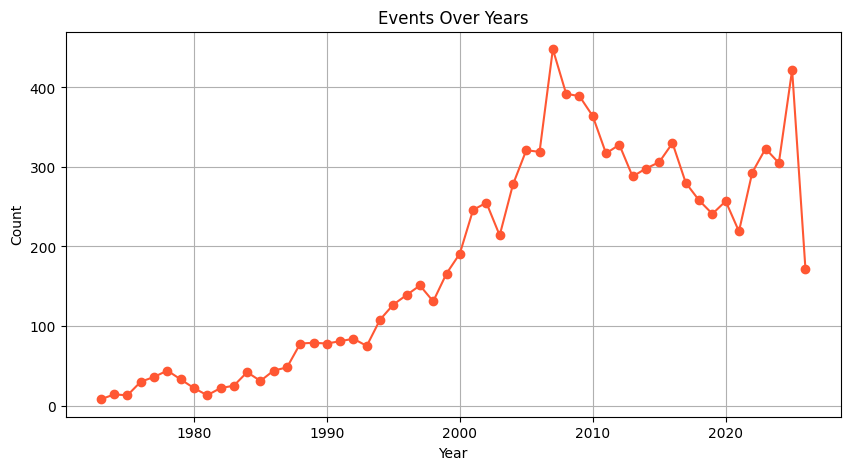

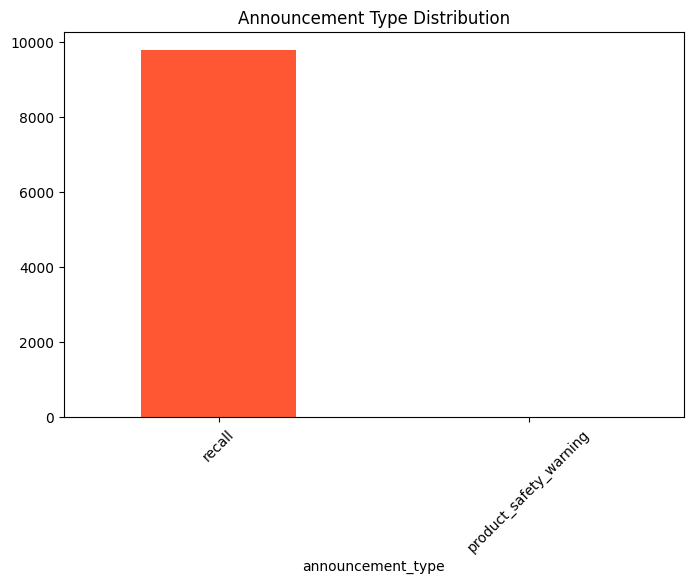

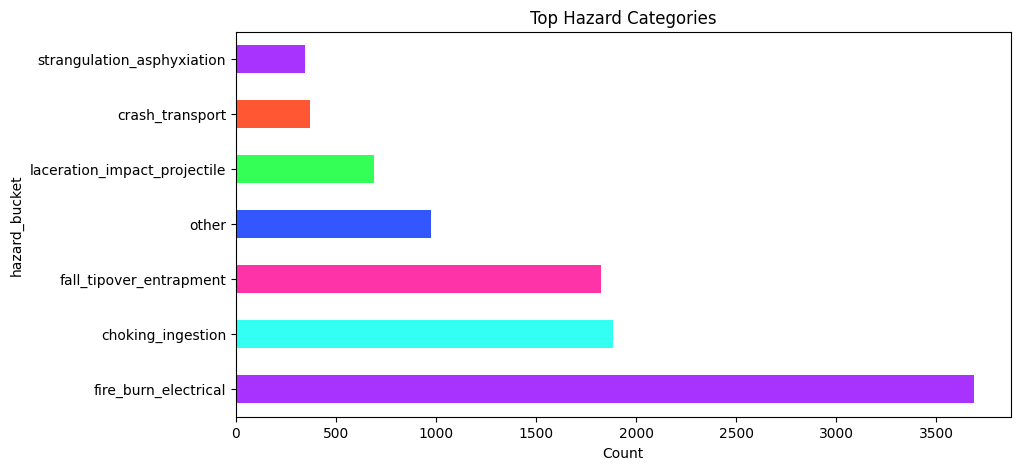

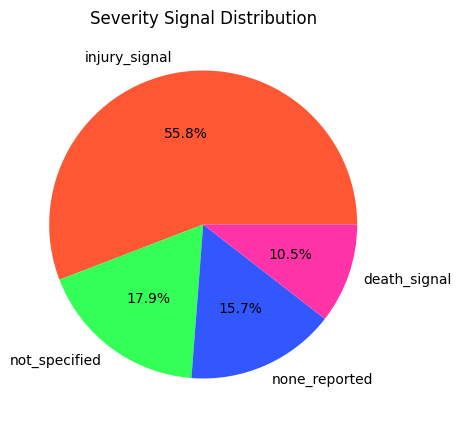

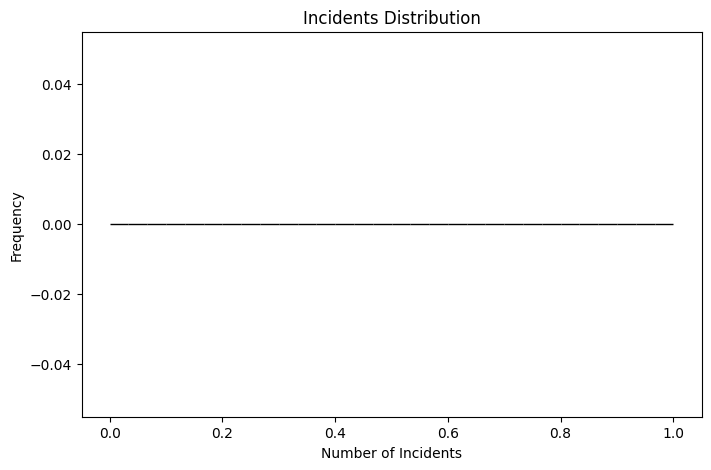

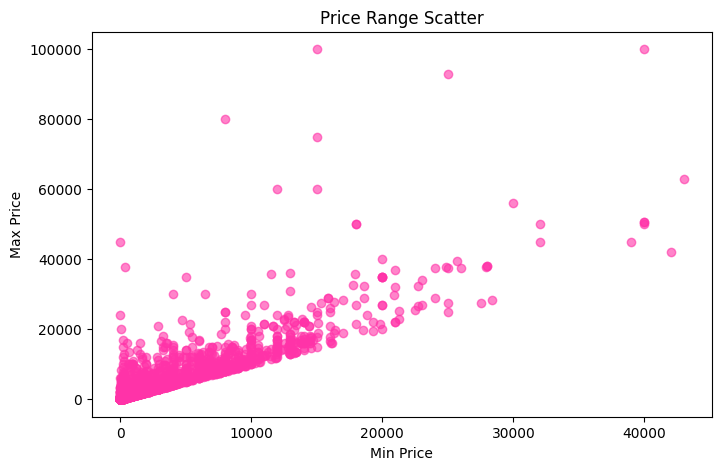

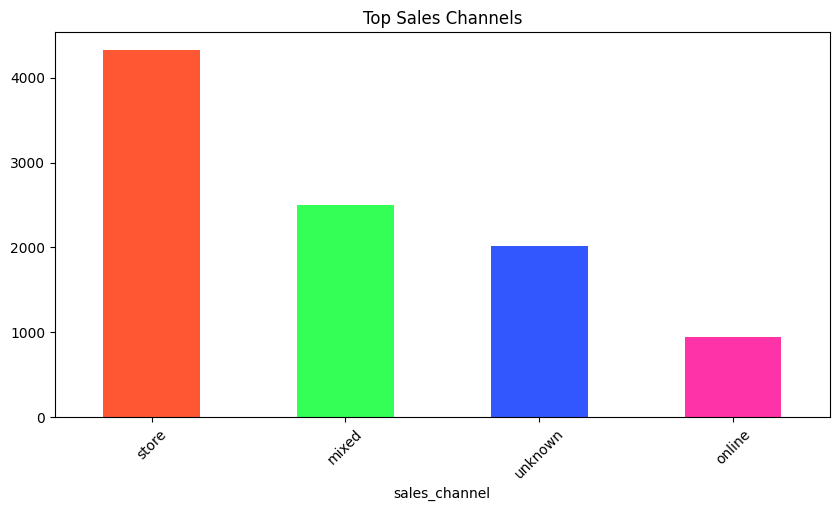

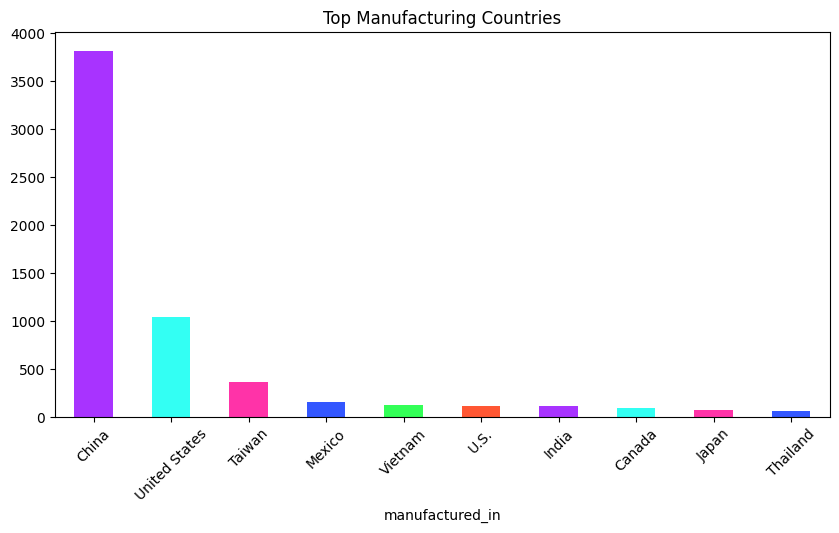

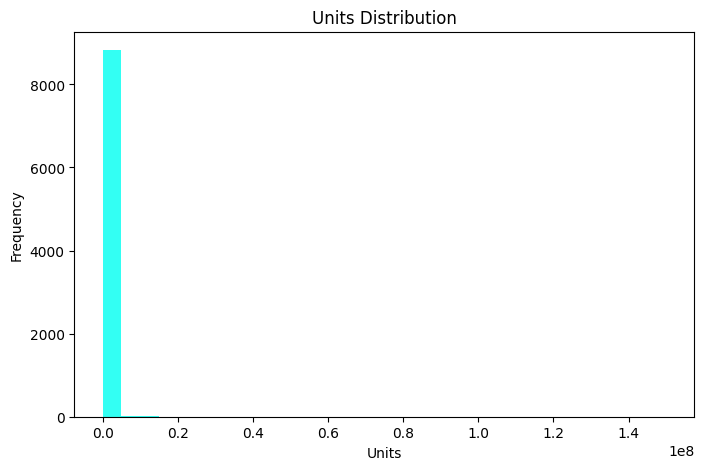

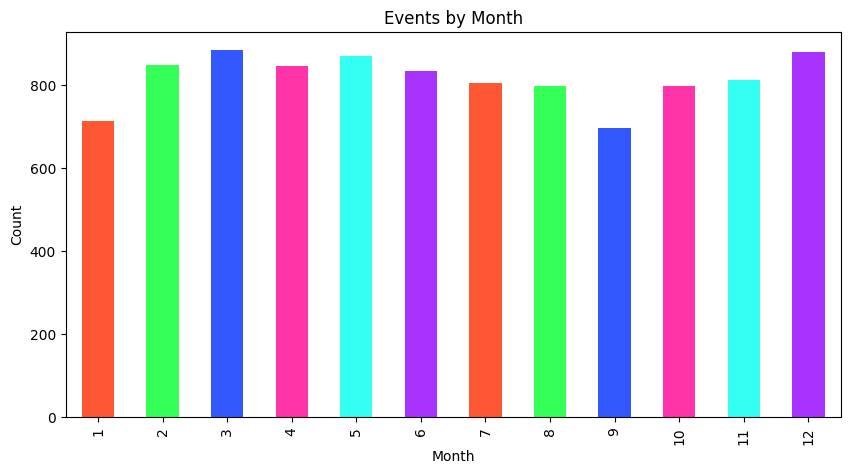

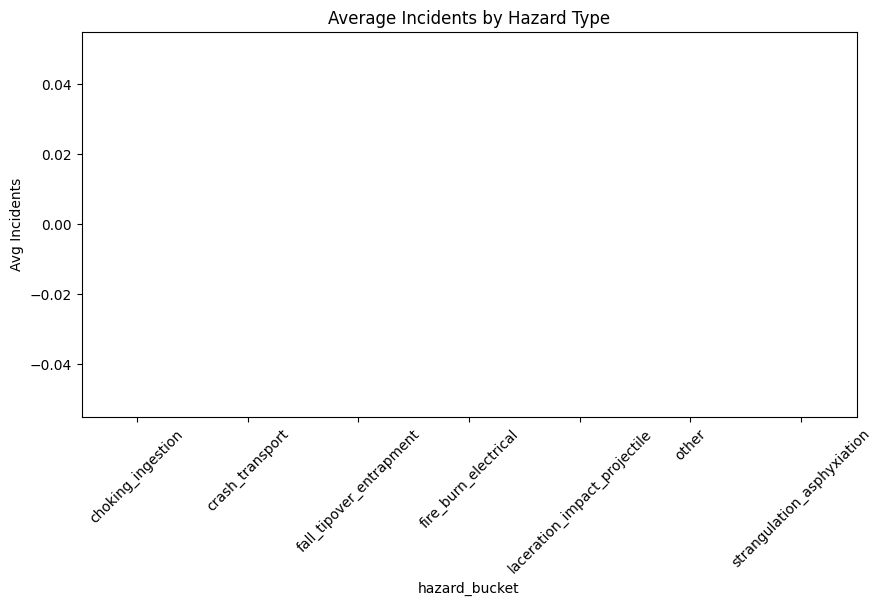

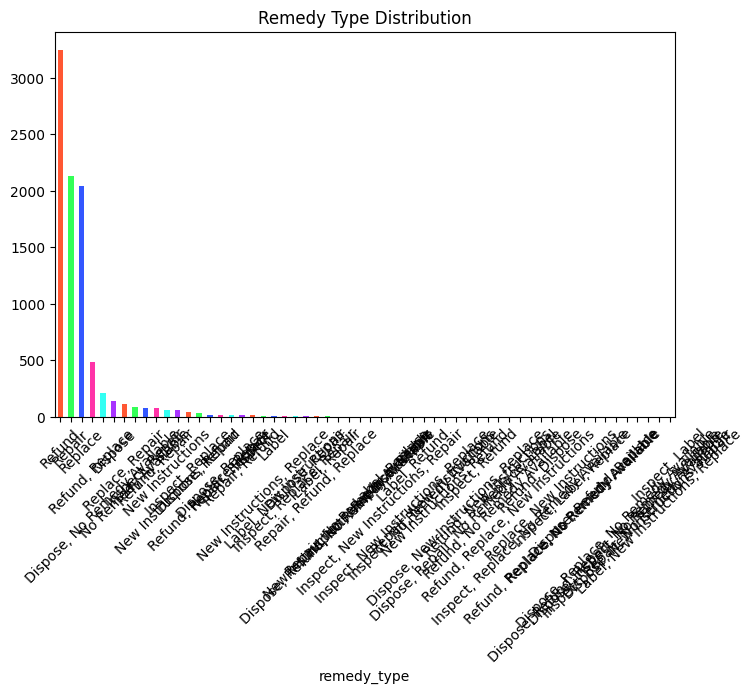

All visualizations generated successfully!


In [13]:
# =========================
# DATA PREPROCESSING
# =========================
# Convert dates
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
df['product_safety_warning_date'] = pd.to_datetime(df['product_safety_warning_date'], errors='coerce')

# Handle missing values
df['units_numeric'] = pd.to_numeric(df['units_numeric'], errors='coerce')
df['price_min_usd'] = pd.to_numeric(df['price_min_usd'], errors='coerce')
df['price_max_usd'] = pd.to_numeric(df['price_max_usd'], errors='coerce')
df['incidents'] = pd.to_numeric(df['incidents'], errors='coerce')

# =========================
# COLOR PALETTE
# =========================
colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A8', '#33FFF3', '#A833FF']

# =========================
# 1. EVENTS OVER TIME
# =========================
plt.figure(figsize=(10,5))
df['event_year'].value_counts().sort_index().plot(
    kind='line', marker='o', color=colors[0]
)
plt.title("Events Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid()
plt.show()

# =========================
# 2. ANNOUNCEMENT TYPE DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['announcement_type'].value_counts().plot(
    kind='bar', color=colors
)
plt.title("Announcement Type Distribution")
plt.xticks(rotation=45)
plt.show()

# =========================
# 3. TOP HAZARD BUCKETS
# =========================
plt.figure(figsize=(10,5))
df['hazard_bucket'].value_counts().head(10).plot(
    kind='barh', color=colors[::-1]
)
plt.title("Top Hazard Categories")
plt.xlabel("Count")
plt.show()

# =========================
# 4. SEVERITY SIGNAL DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['severity_signal'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=colors
)
plt.title("Severity Signal Distribution")
plt.ylabel('')
plt.show()

# =========================
# 5. INCIDENTS DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['incidents'].dropna().plot(
    kind='hist', bins=30, color=colors[2], edgecolor='black'
)
plt.title("Incidents Distribution")
plt.xlabel("Number of Incidents")
plt.show()

# =========================
# 6. PRICE RANGE ANALYSIS
# =========================
plt.figure(figsize=(8,5))
plt.scatter(
    df['price_min_usd'], df['price_max_usd'],
    c=colors[3], alpha=0.6
)
plt.title("Price Range Scatter")
plt.xlabel("Min Price")
plt.ylabel("Max Price")
plt.show()

# =========================
# 7. SALES CHANNEL DISTRIBUTION
# =========================
plt.figure(figsize=(10,5))
df['sales_channel'].value_counts().head(5).plot(
    kind='bar', color=colors
)
plt.title("Top Sales Channels")
plt.xticks(rotation=45)
plt.show()

# =========================
# 8. MANUFACTURED COUNTRY ANALYSIS
# =========================
plt.figure(figsize=(10,5))
df['manufactured_in'].value_counts().head(10).plot(
    kind='bar', color=colors[::-1]
)
plt.title("Top Manufacturing Countries")
plt.xticks(rotation=45)
plt.show()

# =========================
# 9. UNITS DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['units_numeric'].dropna().plot(
    kind='hist', bins=30, color=colors[4]
)
plt.title("Units Distribution")
plt.xlabel("Units")
plt.show()

# =========================
# 10. EVENTS BY MONTH
# =========================
plt.figure(figsize=(10,5))
df['event_month'].value_counts().sort_index().plot(
    kind='bar', color=colors
)
plt.title("Events by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# =========================
# 11. HAZARD VS INCIDENTS
# =========================
hazard_incidents = df.groupby('hazard_bucket')['incidents'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
hazard_incidents.plot(
    kind='bar', color=colors
)
plt.title("Average Incidents by Hazard Type")
plt.ylabel("Avg Incidents")
plt.xticks(rotation=45)
plt.show()

# =========================
# 12. REMEDY TYPE DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['remedy_type'].value_counts().plot(
    kind='bar', color=colors
)
plt.title("Remedy Type Distribution")
plt.xticks(rotation=45)
plt.show()

# =========================
# DONE
# =========================
print("All visualizations generated successfully!")

## Feature engineering


========== Logistic Regression ==========
Accuracy: 0.5573

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       205
           1       0.56      1.00      0.72      1092
           2       0.00      0.00      0.00       308
           3       0.00      0.00      0.00       351

    accuracy                           0.56      1956
   macro avg       0.14      0.25      0.18      1956
weighted avg       0.31      0.56      0.40      1956



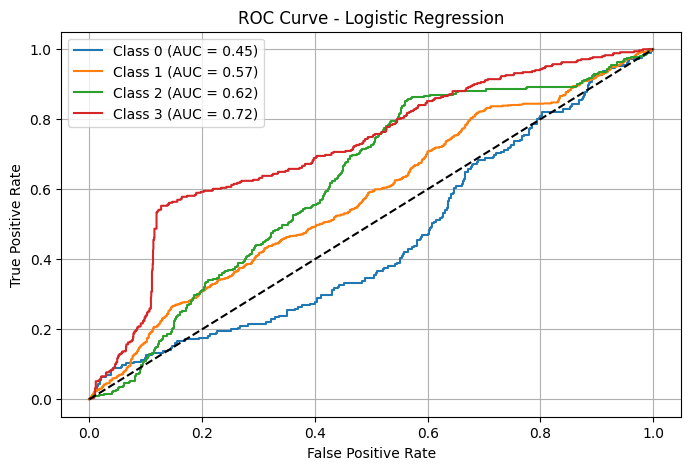


========== Decision Tree ==========
Accuracy: 0.5435

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.37      0.35       205
           1       0.67      0.64      0.65      1092
           2       0.39      0.39      0.39       308
           3       0.45      0.47      0.46       351

    accuracy                           0.54      1956
   macro avg       0.46      0.47      0.46      1956
weighted avg       0.55      0.54      0.55      1956



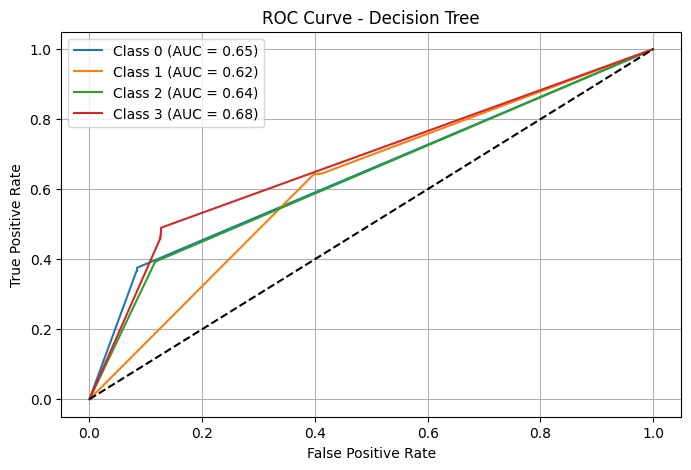


========== Random Forest ==========
Accuracy: 0.6697

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.31      0.43       205
           1       0.67      0.92      0.77      1092
           2       0.60      0.33      0.42       308
           3       0.76      0.40      0.53       351

    accuracy                           0.67      1956
   macro avg       0.68      0.49      0.54      1956
weighted avg       0.67      0.67      0.64      1956



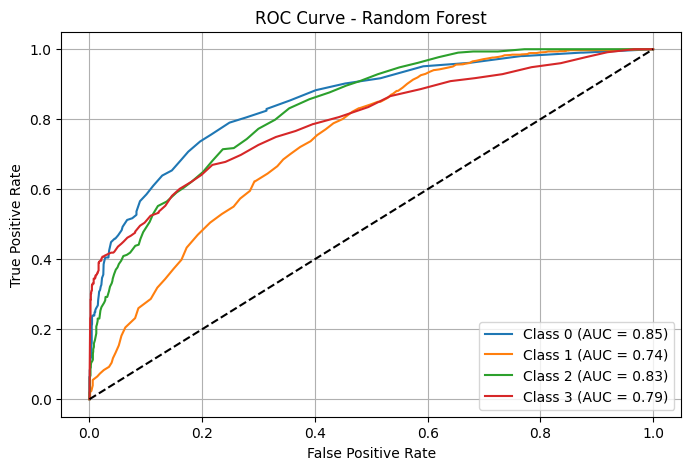

Model training & evaluation completed successfully!


In [14]:
# =========================
# IMPORT LIBRARIES
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# =========================
# SELECT IMPORTANT FEATURES
# =========================
columns_to_use = [
    'announcement_type', 'hazard_bucket', 'remedy_type',
    'sales_channel', 'manufactured_in', 'units_numeric',
    'incidents', 'price_min_usd', 'price_max_usd',
    'event_year', 'event_month'
]

df = df[columns_to_use + ['severity_signal']]

# =========================
# DATA CLEANING
# =========================
df = df.dropna(subset=['severity_signal'])  # Target must not be null

# Fill numeric
numeric_cols = ['units_numeric', 'incidents', 'price_min_usd', 'price_max_usd']
df[numeric_cols] = df[numeric_cols].fillna(0)

# Fill categorical
categorical_cols = ['announcement_type', 'hazard_bucket', 'remedy_type',
                    'sales_channel', 'manufactured_in']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# =========================
# SPLIT FEATURES & TARGET
# =========================
X = df.drop('severity_signal', axis=1)
y = df['severity_signal']

# =========================
# TRAIN TEST SPLIT (BEFORE ENCODING → avoids leakage)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# LABEL ENCODING (NO LEAKAGE)
# =========================
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit ONLY on training data
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen labels in test
    X_test[col] = X_test[col].map(lambda s: '<UNK>' if s not in le.classes_ else s)
    le.classes_ = np.append(le.classes_, '<UNK>')
    X_test[col] = le.transform(X_test[col])
    
    encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# =========================
# TRAIN & EVALUATE
# =========================
for name, model in models.items():
    print(f"\n========== {name} ==========")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # =========================
    # ROC CURVE (Multi-class)
    # =========================
    n_classes = len(np.unique(y_test))
    
    plt.figure(figsize=(8,5))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
    
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

# =========================
# FINAL MESSAGE
# =========================
print("Model training & evaluation completed successfully!")

## Thank you...pls upvote!!!!!!!!